# Candidate Pool — Exploratory Data Analysis
Load the entire `candidates.jsonl` into memory for interactive exploration.

In [1]:
import json
import pandas as pd
from pathlib import Path

CANDIDATES_PATH = Path('../challenge_dataset/candidates.jsonl') #the data directory has not been committed to Github due to its size.

# Read every line into a list of dicts
records = []
with CANDIDATES_PATH.open('r', encoding='utf-8') as fh:
    for line in fh:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f'Loaded {len(records):,} candidates')
print(f'Keys in records: {list(records[0].keys())}')

Loaded 100,000 candidates
Keys in records: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']


In [2]:
# Inspecting dictionary structure.
import pprint
pprint.pprint(records[0])

{'candidate_id': 'CAND_0000001',
 'career_history': [{'company': 'Mindtree',
                     'company_size': '10001+',
                     'description': 'Implemented streaming data pipelines on '
                                    'Kafka and Spark Streaming for a real-time '
                                    'user-activity processing platform. '
                                    'Designed the schema-registry integration, '
                                    'the watermark/state management approach, '
                                    'and the deduplication logic for '
                                    'late-arriving events. Worked closely with '
                                    'the data science team to make sure '
                                    'feature pipelines aligned with what their '
                                    'models needed. Most of my career has been '
                                    'data engineering, with some adjacent ML '
              

<h3> Inspect Titles </h3>

In [3]:
# Count of all unique current_title values across the dataset
from collections import Counter

title_counts = Counter(
    c['profile'].get('current_title', '').strip()
    for c in records
    if c.get('profile', {}).get('current_title')
)

# Convert to a sorted DataFrame (most common first)
df_titles = (
    pd.DataFrame(title_counts.most_common(), columns=['Title', 'Count'])
    .reset_index(drop=True)
)
df_titles.index += 1

print(f'Unique titles: {len(df_titles):,}')
df_titles.head(len(df_titles))


Unique titles: 47


,Title,Count
1,Business Analyst,5833
2,HR Manager,5830
3,Mechanical Engineer,5791
4,Accountant,5764
5,Project Manager,5754
6,Customer Support,5750
7,Operations Manager,5744
8,Content Writer,5727
9,Sales Executive,5713
10,Civil Engineer,5702


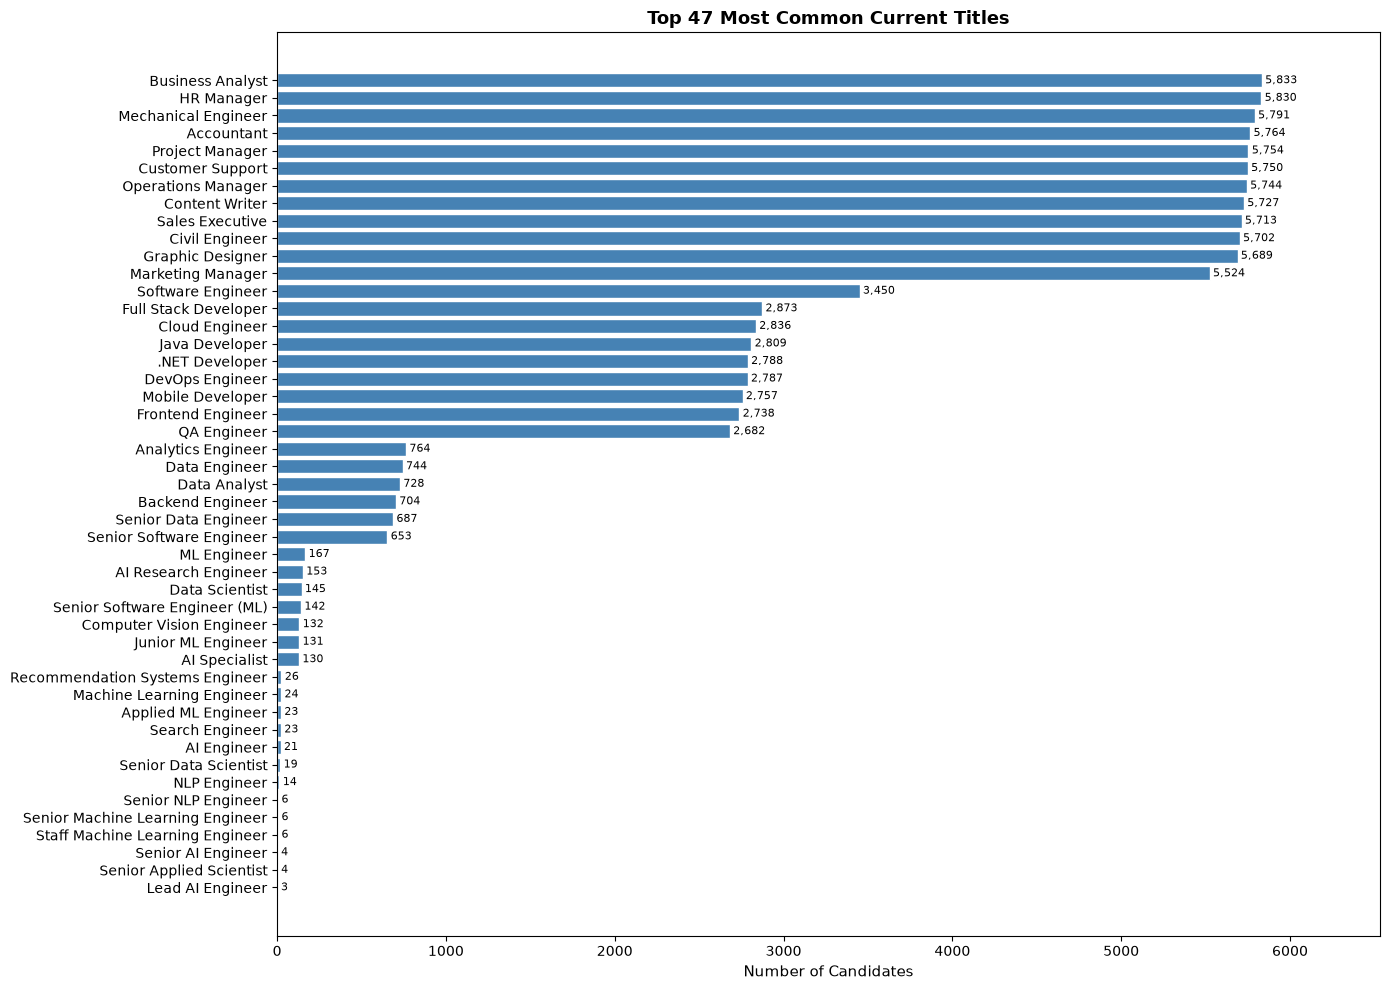

In [4]:
#Bar chart:most common current titles
import matplotlib.pyplot as plt

TOP = 47
top_df = df_titles.head(TOP)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(top_df['Title'][::-1], top_df['Count'][::-1], color='steelblue', edgecolor='white')

# Label each bar with its count
for bar, val in zip(bars, top_df['Count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

ax.set_xlabel('Number of Candidates', fontsize=11)
ax.set_title(f'Top {TOP} Most Common Current Titles', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_df['Count'].max() * 1.12)
plt.tight_layout()
plt.show()


In [5]:
#Inspecting career history

rows = []
for c in records:
    cid     = c.get('candidate_id', '')
    profile = c.get('profile', {}) or {}
    career  = c.get('career_history', []) or []

    current = profile.get('current_title', '')

    # Sort jobs by start_date descending so index 0 = most recent previous job
    past_jobs = sorted(
        [j for j in career if not j.get('is_current', False) and j.get('start_date')],
        key=lambda j: j['start_date'],
        reverse=True
    )

    prev1 = past_jobs[0]['title'] if len(past_jobs) > 0 else ''
    prev2 = past_jobs[1]['title'] if len(past_jobs) > 1 else ''

    rows.append({
        'candidate_id'     : cid,
        'current_title'    : current,
        'previous_title_1' : prev1,
        'previous_title_2' : prev2,
    })

df_career = (
    pd.DataFrame(rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

pd.set_option('display.max_rows', 500)
print(f'{len(df_career):,} candidates')
df_career.head(20)


100,000 candidates


,candidate_id,current_title,previous_title_1,previous_title_2
0,CAND_0000001,Backend Engineer,Analytics Engineer,
1,CAND_0000002,Operations Manager,Operations Manager,Marketing Manager
2,CAND_0000003,Customer Support,,
3,CAND_0000004,Marketing Manager,Operations Manager,Business Analyst
4,CAND_0000005,Accountant,HR Manager,HR Manager
5,CAND_0000006,Business Analyst,Mechanical Engineer,
6,CAND_0000007,Civil Engineer,Mechanical Engineer,
7,CAND_0000008,Operations Manager,,
8,CAND_0000009,Mechanical Engineer,Content Writer,Customer Support
9,CAND_0000010,Data Engineer,,


In [6]:
#Create a list of Tech roles Job Titles for the JD.
tech_roles = ['Software Engineer', 'Full Stack Developer', 'Cloud Engineer', '.NET Developer', 'Java Developer', 'Mobile Developer', 'Devops Engineer', 'Frontend Engineer', 'QA Engineer', 'Analytics Engineer',  'Data Engineer', 'Data Analyst', 'Backend Engineer' , 'Senior Data Engineer', 'Senior Software Engineer', 'ML Engineer', 'AI Research Engineer', 'Data Scientist', 'Senior Software Engineer (ML)', 'Computer Vision Engineer', 'Junior ML Engineer', 'AI Specialist', 'Recommendation Systems Engineer', 'Machine Learning Engineer' , 'Applied ML Engineer', 'Search Engineer', 'AI Engineer', 'Senior Data Scientist', 'NLP Engineer', 'Senior NLP Engineer', 'Senior Machine Learning Engineer', 'Staff Machine Learning Engineer','Senior AI Engineer', 'Lead AI Engineer', 'Senior Applied Scientist' ]

<h3> Inspect Skills </h3>

In [7]:
from collections import Counter

skill_counts = Counter(
    s.get('name', '').strip()
    for c in records
    for s in c.get('skills', [])
    if s.get('name', '').strip()
)

all_skills = [skill for skill, count in skill_counts.most_common()]

print(f'Total unique skills: {len(all_skills)}\n')
for i, skill in enumerate(all_skills, 1):
    print(f'{i:>4}. {skill}')

Total unique skills: 133

   1. HTML
   2. Databricks
   3. Redux
   4. Terraform
   5. Angular
   6. Figma
   7. Salesforce CRM
   8. Vue.js
   9. Sales
  10. Accounting
  11. Agile
  12. Kafka
  13. Excel
  14. BigQuery
  15. CI/CD
  16. Project Management
  17. Airflow
  18. AWS
  19. Flask
  20. Scrum
  21. Illustrator
  22. Kubernetes
  23. ETL
  24. CSS
  25. Docker
  26. Next.js
  27. Apache Beam
  28. Java
  29. Go
  30. TypeScript
  31. JavaScript
  32. dbt
  33. REST APIs
  34. Spark
  35. Marketing
  36. Tally
  37. GraphQL
  38. Snowflake
  39. Webpack
  40. Six Sigma
  41. SEO
  42. SAP
  43. GCP
  44. PostgreSQL
  45. Rust
  46. Apache Flink
  47. gRPC
  48. Content Writing
  49. SQL
  50. Hadoop
  51. Redis
  52. Tailwind
  53. Photoshop
  54. FastAPI
  55. Microservices
  56. PowerPoint
  57. Spring Boot
  58. Data Pipelines
  59. Django
  60. MongoDB
  61. Node.js
  62. Azure
  63. React
  64. Hugging Face Transformers
  65. LangChain
  66. Information Retrieval
  67. 

<h3> Inspecting Company diversity </h3>

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

# Count every company ever mentioned across all career history entries
company_counts = Counter(
    job.get('company', '').strip()
    for c in records
    for job in c.get('career_history', [])
    if job.get('company', '').strip()
)

df_companies = (
    pd.DataFrame(company_counts.most_common(), columns=['Company', 'Count'])
    .reset_index(drop=True)
)
df_companies.index += 1

print(f'Unique companies in dataset : {len(df_companies):,}')
print(f'Total company mentions      : {sum(company_counts.values()):,}')
df_companies.head(len(df_companies))


Unique companies in dataset : 63
Total company mentions      : 300,171


,Company,Count
1,Infosys,23722
2,Wipro,23682
3,Pied Piper,23614
4,Initech,23590
5,Wayne Enterprises,23556
6,Acme Corp,23546
7,Stark Industries,23524
8,Hooli,23509
9,TCS,23483
10,Globex Inc,23471


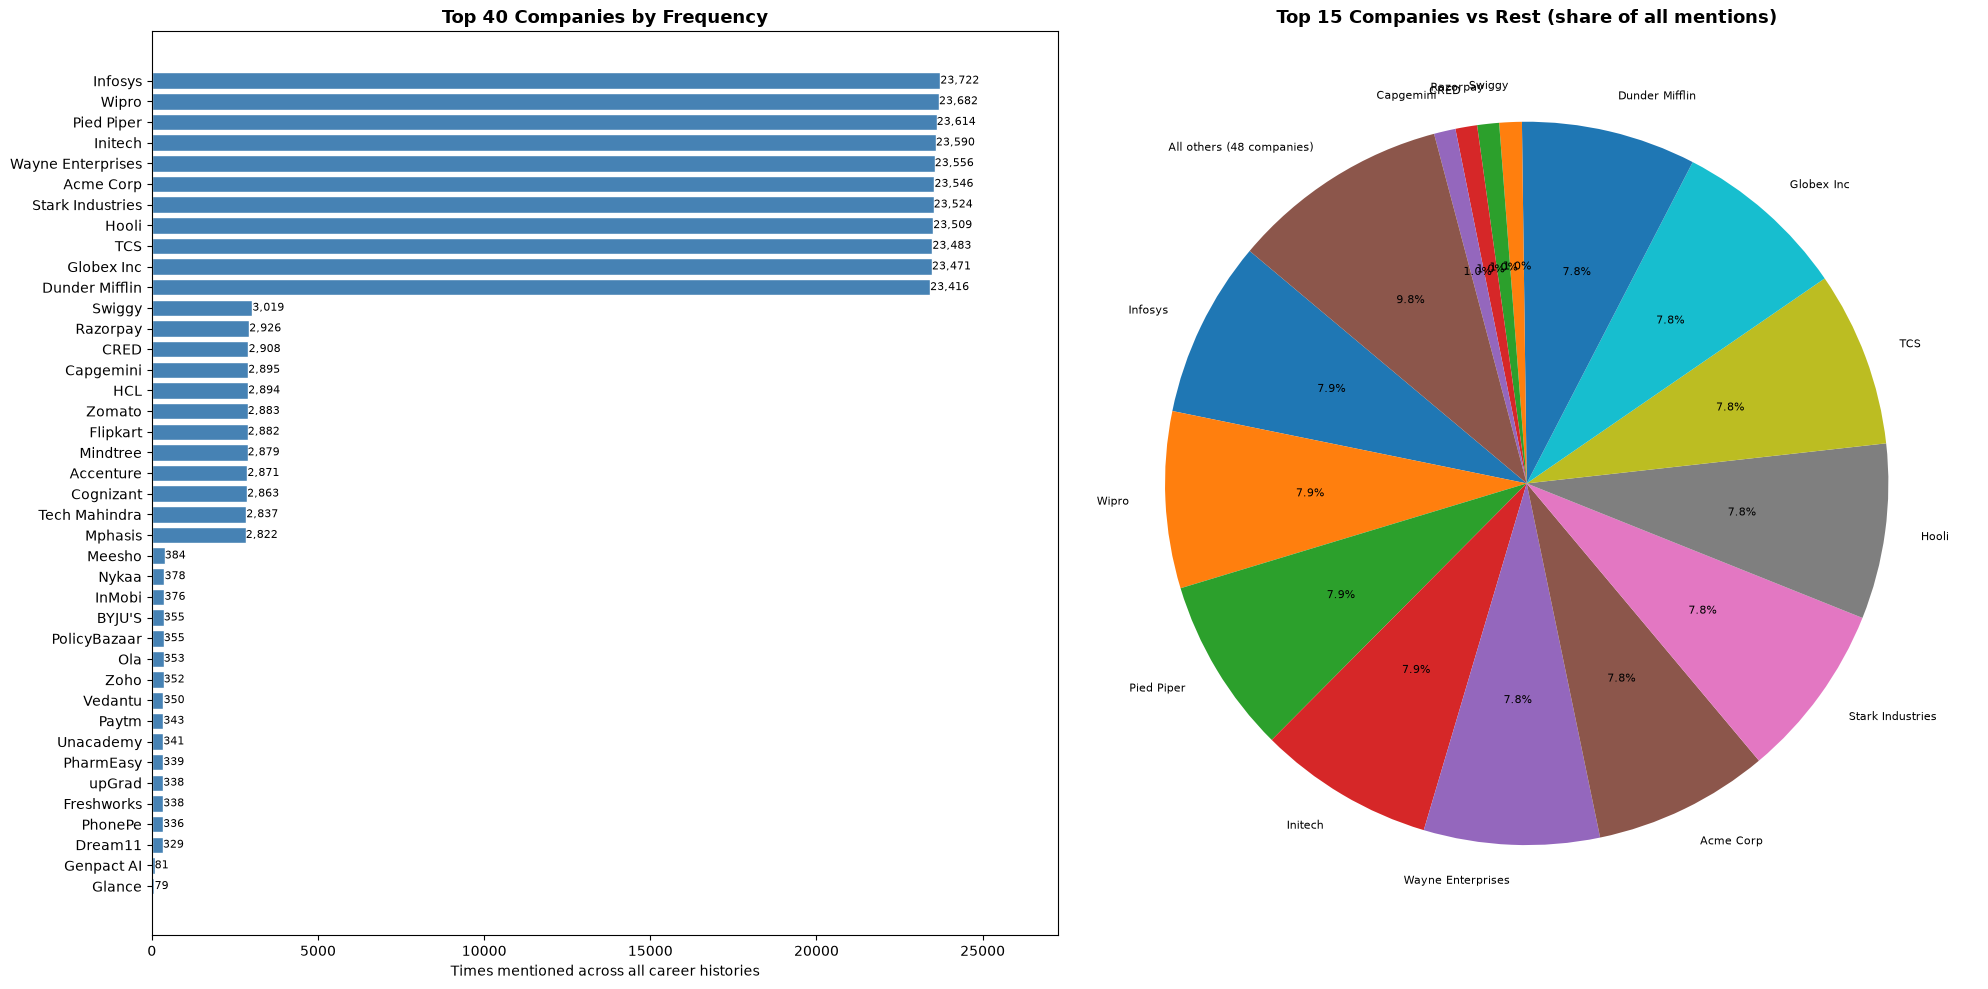

In [9]:
TOP = 40
top_companies = df_companies.head(TOP)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# top 40 companies
bars = axes[0].barh(
    top_companies['Company'][::-1],
    top_companies['Count'][::-1],
    color='steelblue', edgecolor='white'
)
for bar, val in zip(bars, top_companies['Count'][::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8)
axes[0].set_xlabel('Times mentioned across all career histories')
axes[0].set_title(f'Top {TOP} Companies by Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, top_companies['Count'].max() * 1.15)

#Pie chart: top 15 vs rest 
TOP_PIE = 15
pie_data  = list(top_companies['Count'][:TOP_PIE]) + [df_companies['Count'][TOP_PIE:].sum()]
pie_labels = list(top_companies['Company'][:TOP_PIE]) + [f'All others ({len(df_companies) - TOP_PIE:,} companies)']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title(f'Top {TOP_PIE} Companies vs Rest (share of all mentions)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
# list of companies.
all_companies = [company for company, count in company_counts.most_common()]
print(all_companies)


['Infosys', 'Wipro', 'Pied Piper', 'Initech', 'Wayne Enterprises', 'Acme Corp', 'Stark Industries', 'Hooli', 'TCS', 'Globex Inc', 'Dunder Mifflin', 'Swiggy', 'Razorpay', 'CRED', 'Capgemini', 'HCL', 'Zomato', 'Flipkart', 'Mindtree', 'Accenture', 'Cognizant', 'Tech Mahindra', 'Mphasis', 'Meesho', 'Nykaa', 'InMobi', "BYJU'S", 'PolicyBazaar', 'Ola', 'Zoho', 'Vedantu', 'Paytm', 'Unacademy', 'PharmEasy', 'upGrad', 'Freshworks', 'PhonePe', 'Dream11', 'Genpact AI', 'Glance', 'Rephrase.ai', 'Aganitha', 'Niramai', 'Saarthi.ai', 'Sarvam AI', 'Mad Street Den', 'Observe.AI', 'Krutrim', 'Wysa', 'Haptik', 'Verloop.io', 'Yellow.ai', 'Locobuzz', 'Google', 'Netflix', 'Amazon', 'Salesforce', 'Uber', 'Meta', 'Adobe', 'Microsoft', 'Apple', 'LinkedIn']


In [11]:
#list of pure-consulting companies and fake companies. The JD asks us to avoid candidates who have only ever worked in pure consulting companies.
#The following list is not exhaustive, but it covers all the common consulting companies available in the dataset.

consulting_companies = ['Infosys', 'Wipro', 'TCS', 'Capgemini', 'HCL', 'Mindtree', 'Accenture', 'Cognizant', 'Tech Mahindra', 'Mphasis']
fictional_companies = ['Pied Piper', 'Initech', 'Wayne Enterprises', 'Stark Industries', 'Hooli', 'Dunder Mifflin', 'Globex Inc', 'Acme Corp']

#To figure-out --> [Globex Inc, Acme Corp] -> a real company or the fictional company from The Simpsons?

In [12]:
#Create a dataframe to find out consulting_only candidates. 
consulting_set = {c.lower() for c in consulting_companies}

rows = []
for c in records:
    cid    = c.get('candidate_id', '')
    career = c.get('career_history', []) or []

    # Sort by start_date descending → most recent first
    sorted_jobs = sorted(
        [j for j in career if j.get('start_date')],
        key=lambda j: j['start_date'],
        reverse=True
    )

    all_companies = [j.get('company', '').strip() for j in sorted_jobs if j.get('company', '').strip()]

    company_n   = all_companies[0] if len(all_companies) > 0 else ''
    company_n1  = all_companies[1] if len(all_companies) > 1 else ''
    company_n2  = all_companies[2] if len(all_companies) > 2 else ''

    # consulting_only = True only if every company in the full history is a consulting firm
    if all_companies:
        consulting_only = all(co.lower() in consulting_set for co in all_companies)
    else:
        consulting_only = False

    rows.append({
        'candidate_id'   : cid,
        'company_n'      : company_n,
        'company_(n-1)'  : company_n1,
        'company_(n-2)'  : company_n2,
        'consulting_only': consulting_only,
    })

df_consulting = (
    pd.DataFrame(rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

print(f"Total candidates      : {len(df_consulting):,}")
print(f"Consulting-only (True): {df_consulting['consulting_only'].sum():,}")
print(f"Mixed/product  (False): {(~df_consulting['consulting_only']).sum():,}")
df_consulting.head(50)

Total candidates      : 100,000
Consulting-only (True): 9,745
Mixed/product  (False): 90,255


,candidate_id,company_n,company_(n-1),company_(n-2),consulting_only
0,CAND_0000001,Mindtree,Dunder Mifflin,,False
1,CAND_0000002,Wipro,Wipro,Acme Corp,False
2,CAND_0000003,TCS,,,True
3,CAND_0000004,Dunder Mifflin,Infosys,Globex Inc,False
4,CAND_0000005,Stark Industries,Wipro,Initech,False
5,CAND_0000006,Wayne Enterprises,Pied Piper,,False
6,CAND_0000007,Wipro,Initech,,False
7,CAND_0000008,Wipro,,,True
8,CAND_0000009,Dunder Mifflin,Wipro,Stark Industries,False
9,CAND_0000010,Ola,,,False


In [13]:
fictional_set = {c.lower() for c in fictional_companies}

rows = []
for c in records:
    cid    = c.get('candidate_id', '')
    career = c.get('career_history', []) or []

    sorted_jobs = sorted(
        [j for j in career if j.get('start_date')],
        key=lambda j: j['start_date'],
        reverse=True
    )

    all_companies = [j.get('company', '').strip() for j in sorted_jobs if j.get('company', '').strip()]

    company_n  = all_companies[0] if len(all_companies) > 0 else ''
    company_n1 = all_companies[1] if len(all_companies) > 1 else ''
    company_n2 = all_companies[2] if len(all_companies) > 2 else ''

    has_fictional     = any(co.lower() in fictional_set for co in all_companies)
    has_non_fictional = any(co.lower() not in fictional_set for co in all_companies)

    fictional_only = has_fictional and not has_non_fictional
    mixed          = has_fictional and has_non_fictional

    rows.append({
        'candidate_id'  : cid,
        'company_n'     : company_n,
        'company_(n-1)' : company_n1,
        'company_(n-2)' : company_n2,
        'fictional_only': fictional_only,
        'mixed'         : mixed,
    })

df_fictional = (
    pd.DataFrame(rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

print(f"fictional_only: {df_fictional['fictional_only'].sum():,}")
print(f"mixed: {df_fictional['mixed'].sum():,}")
print(f"Total                 : {len(df_fictional):,}")
df_fictional


fictional_only: 31,034
mixed: 50,490
Total                 : 100,000


,candidate_id,company_n,company_(n-1),company_(n-2),fictional_only,mixed
0,CAND_0000001,Mindtree,Dunder Mifflin,,False,True
1,CAND_0000002,Wipro,Wipro,Acme Corp,False,True
2,CAND_0000003,TCS,,,False,False
3,CAND_0000004,Dunder Mifflin,Infosys,Globex Inc,False,True
4,CAND_0000005,Stark Industries,Wipro,Initech,False,True
...,...,...,...,...,...,...
99995,CAND_0099996,Wipro,Hooli,Dunder Mifflin,False,True
99996,CAND_0099997,Hooli,Hooli,Wayne Enterprises,False,True
99997,CAND_0099998,InMobi,Ola,Mphasis,False,False
99998,CAND_0099999,HCL,Stark Industries,,False,True


Total candidates          : 100,000
Must avoid                : 91,269  (91.3%)
  └─ Consulting only      : 9,745
  └─ Has fictional company: 81,524
Clean (neither flag)      : 8,731  (8.7%)


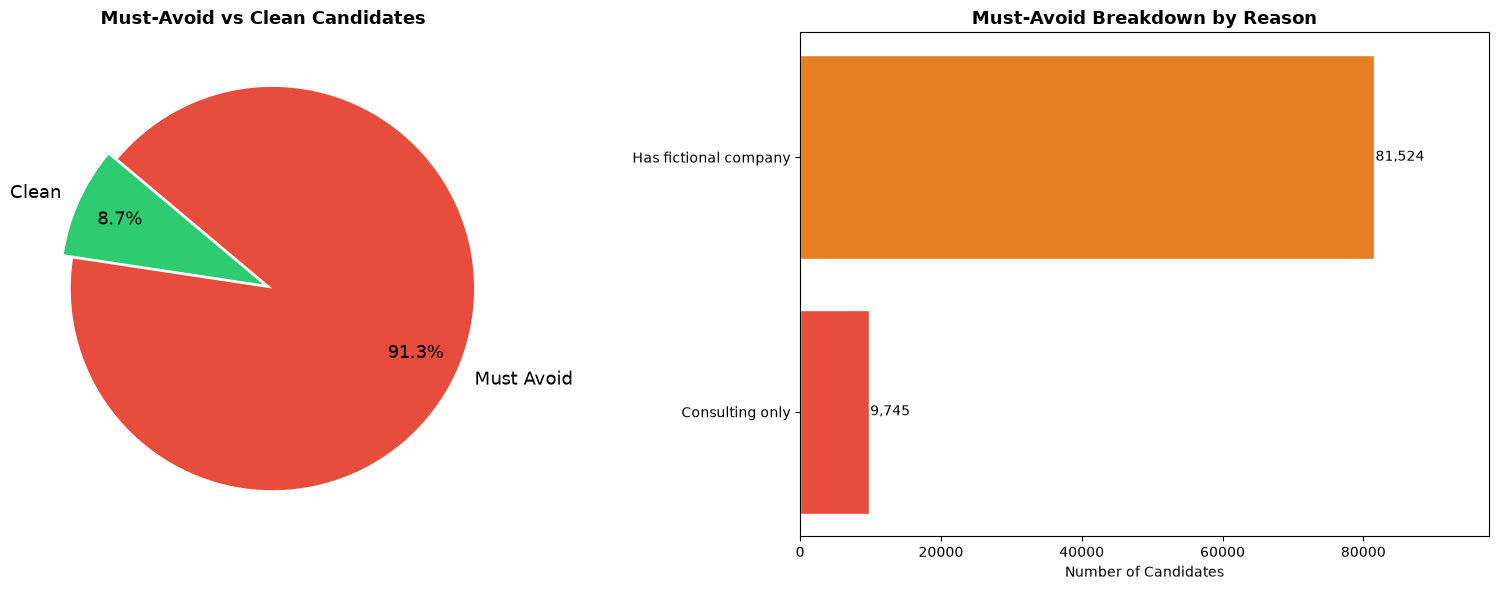

,candidate_id,consulting_only,has_fictional,reason
0,CAND_0000001,False,True,Has fictional company
1,CAND_0000002,False,True,Has fictional company
2,CAND_0000003,True,False,Consulting only
3,CAND_0000004,False,True,Has fictional company
4,CAND_0000005,False,True,Has fictional company
...,...,...,...,...
91264,CAND_0099995,False,True,Has fictional company
91265,CAND_0099996,False,True,Has fictional company
91266,CAND_0099997,False,True,Has fictional company
91267,CAND_0099999,False,True,Has fictional company


In [14]:
import matplotlib.pyplot as plt

# Merge consulting and fictional flags
df_avoid = df_consulting[['candidate_id', 'consulting_only']].merge(
    df_fictional[['candidate_id', 'fictional_only', 'mixed']],
    on='candidate_id',
    how='left'
)

# has_fictional = appeared in any fictional company (either fully or partially)
df_avoid['has_fictional'] = df_avoid['fictional_only'] | df_avoid['mixed']
df_avoid['must_avoid']    = df_avoid['consulting_only'] | df_avoid['has_fictional']

def avoid_reason(row):
    reasons = []
    if row['consulting_only']: reasons.append('Consulting only')
    if row['has_fictional']:   reasons.append('Has fictional company')
    return ' + '.join(reasons) if reasons else 'Clean'

df_avoid['reason'] = df_avoid.apply(avoid_reason, axis=1)

total        = len(df_avoid)
n_must_avoid = int(df_avoid['must_avoid'].sum())
n_clean      = total - n_must_avoid
n_consulting = int(df_avoid['consulting_only'].sum())
n_fictional  = int(df_avoid['has_fictional'].sum())
n_both       = int((df_avoid['consulting_only'] & df_avoid['has_fictional']).sum())

print(f"Total candidates          : {total:,}")
print(f"Must avoid                : {n_must_avoid:,}  ({100*n_must_avoid/total:.1f}%)")
print(f"  └─ Consulting only      : {n_consulting:,}")
print(f"  └─ Has fictional company: {n_fictional:,}")
print(f"Clean (neither flag)      : {n_clean:,}  ({100*n_clean/total:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie: must-avoid vs clean
axes[0].pie(
    [n_clean, n_must_avoid],
    labels=['Clean', 'Must Avoid'],
    colors=['#2ecc71', '#e74c3c'],
    explode=(0, 0.05),
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 13},
    pctdistance=0.78,
)
axes[0].set_title('Must-Avoid vs Clean Candidates', fontsize=13, fontweight='bold')

# Bar: breakdown by reason
reason_counts = df_avoid[df_avoid['must_avoid']]['reason'].value_counts()
bar_colors = ['#e74c3c', '#e67e22', '#c0392b'][:len(reason_counts)]
bars = axes[1].barh(reason_counts.index[::-1], reason_counts.values[::-1],
                    color=bar_colors, edgecolor='white')
for bar, val in zip(bars, reason_counts.values[::-1]):
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=10)
axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Must-Avoid Breakdown by Reason', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, reason_counts.values.max() * 1.2)

plt.tight_layout()
plt.show()

df_avoid[df_avoid['must_avoid']][['candidate_id', 'consulting_only', 'has_fictional', 'reason']].reset_index(drop=True)


Clean candidates           : 8,731
  └─ In tech_roles         : 8,731  (100.0%)
  └─ Not in tech_roles     : 0  (0.0%)


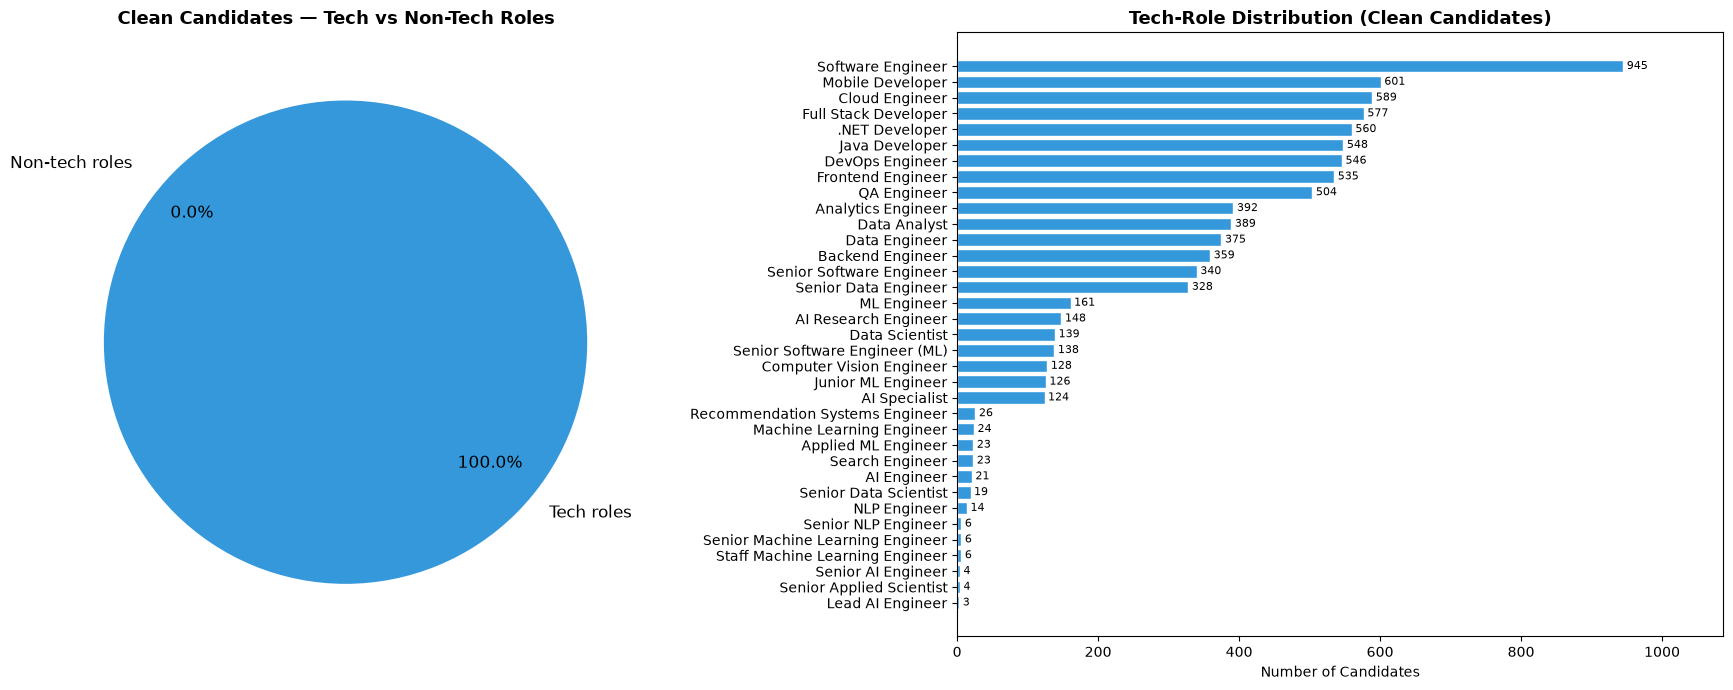

,candidate_id,current_title,is_tech_role
0,CAND_0000010,Data Engineer,True
1,CAND_0000025,Frontend Engineer,True
2,CAND_0000031,Recommendation Systems Engineer,True
3,CAND_0000051,Cloud Engineer,True
4,CAND_0000055,Full Stack Developer,True
...,...,...,...
8726,CAND_0099965,Junior ML Engineer,True
8727,CAND_0099983,Data Engineer,True
8728,CAND_0099984,Analytics Engineer,True
8729,CAND_0099987,.NET Developer,True


In [15]:
import matplotlib.pyplot as plt

tech_roles_set = {t.lower() for t in tech_roles}

# Clean candidate IDs
clean_ids = set(df_avoid[~df_avoid['must_avoid']]['candidate_id'])

# Build a lookup: candidate_id → current_title from records
id_to_title = {
    c.get('candidate_id', ''): (c.get('profile', {}) or {}).get('current_title', '')
    for c in records
}

# Filter to clean candidates only
clean_rows = [
    {
        'candidate_id'  : cid,
        'current_title' : id_to_title.get(cid, ''),
    }
    for cid in clean_ids
]

df_clean = (
    pd.DataFrame(clean_rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

df_clean['is_tech_role'] = df_clean['current_title'].str.lower().isin(tech_roles_set)

n_clean      = len(df_clean)
n_tech       = int(df_clean['is_tech_role'].sum())
n_non_tech   = n_clean - n_tech

print(f"Clean candidates           : {n_clean:,}")
print(f"  └─ In tech_roles         : {n_tech:,}  ({100*n_tech/n_clean:.1f}%)")
print(f"  └─ Not in tech_roles     : {n_non_tech:,}  ({100*n_non_tech/n_clean:.1f}%)")

# --- Title distribution within tech-role clean candidates ---
tech_title_counts = (
    df_clean[df_clean['is_tech_role']]['current_title']
    .value_counts()
    .reset_index()
)
tech_title_counts.columns = ['Title', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pie: tech vs non-tech within clean pool
axes[0].pie(
    [n_tech, n_non_tech],
    labels=['Tech roles', 'Non-tech roles'],
    colors=['#3498db', '#95a5a6'],
    explode=(0.05, 0),
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 12},
    pctdistance=0.78,
)
axes[0].set_title('Clean Candidates — Tech vs Non-Tech Roles', fontsize=13, fontweight='bold')

# Bar: count per tech title
bars = axes[1].barh(
    tech_title_counts['Title'][::-1],
    tech_title_counts['Count'][::-1],
    color='#3498db', edgecolor='white'
)
for bar, val in zip(bars, tech_title_counts['Count'][::-1]):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8)
axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Tech-Role Distribution (Clean Candidates)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, tech_title_counts['Count'].max() * 1.15)

plt.tight_layout()
plt.show()

df_clean

In [16]:
# Build a fast lookup: candidate_id → full record
id_to_record = {c.get('candidate_id', ''): c for c in records}

rows = []
for cid in clean_ids:
    c      = id_to_record.get(cid, {})
    career = c.get('career_history', []) or []

    # Sort by start_date descending → most recent first
    sorted_jobs = sorted(
        [j for j in career if j.get('start_date')],
        key=lambda j: j['start_date'],
        reverse=True
    )

    def get_company(n): return sorted_jobs[n].get('company', '').strip() if len(sorted_jobs) > n else ''
    def get_title(n):   return sorted_jobs[n].get('title',   '').strip() if len(sorted_jobs) > n else ''

    rows.append({
        'candidate_id'       : cid,
        'company_n'          : get_company(0),
        'company_n_title'    : get_title(0),
        'company_(n-1)'      : get_company(1),
        'company_(n-1)_title': get_title(1),
        'company_(n-2)'      : get_company(2),
        'company_(n-2)_title': get_title(2),
    })

df_clean_career = (
    pd.DataFrame(rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

print(f"Clean candidates with career history: {len(df_clean_career):,}")
df_clean_career.head(101)

Clean candidates with career history: 8,731


,candidate_id,company_n,company_n_title,company_(n-1),company_(n-1)_title,company_(n-2),company_(n-2)_title
0,CAND_0000010,Ola,Data Engineer,,,,
1,CAND_0000025,Tech Mahindra,Frontend Engineer,Mindtree,Frontend Engineer,Zomato,Frontend Engineer
2,CAND_0000031,Swiggy,Recommendation Systems Engineer,Mad Street Den,Search Engineer,Uber,NLP Engineer
3,CAND_0000051,HCL,Cloud Engineer,Zomato,Java Developer,,
4,CAND_0000055,Razorpay,Full Stack Developer,Flipkart,.NET Developer,Cognizant,Mobile Developer
5,CAND_0000063,Mphasis,Java Developer,Swiggy,.NET Developer,,
6,CAND_0000067,Accenture,Frontend Engineer,Swiggy,Mobile Developer,,
7,CAND_0000082,Wipro,Data Analyst,Zomato,Senior Data Engineer,Mindtree,Backend Engineer
8,CAND_0000099,Razorpay,Full Stack Developer,Flipkart,Full Stack Developer,,
9,CAND_0000108,Zomato,Full Stack Developer,Mindtree,Cloud Engineer,,


<h3> Inspecting Location Diversity </h3>

In [17]:
df_locations = pd.DataFrame([
    {
        'candidate_id' : c.get('candidate_id', ''),
        'country'      : (c.get('profile', {}) or {}).get('country', ''),
        'location'     : (c.get('profile', {}) or {}).get('location', ''),
    }
    for c in records
]).sort_values('candidate_id').reset_index(drop=True)

print(f'{len(df_locations):,} candidates')
df_locations

100,000 candidates


,candidate_id,country,location
0,CAND_0000001,Canada,Toronto
1,CAND_0000002,India,"Chennai, Tamil Nadu"
2,CAND_0000003,USA,Austin
3,CAND_0000004,Australia,Sydney
4,CAND_0000005,India,"Gurgaon, Haryana"
...,...,...,...
99995,CAND_0099996,India,"Ahmedabad, Gujarat"
99996,CAND_0099997,India,"Bangalore, Karnataka"
99997,CAND_0099998,India,"Kochi, Kerala"
99998,CAND_0099999,India,"Bhubaneswar, Odisha"


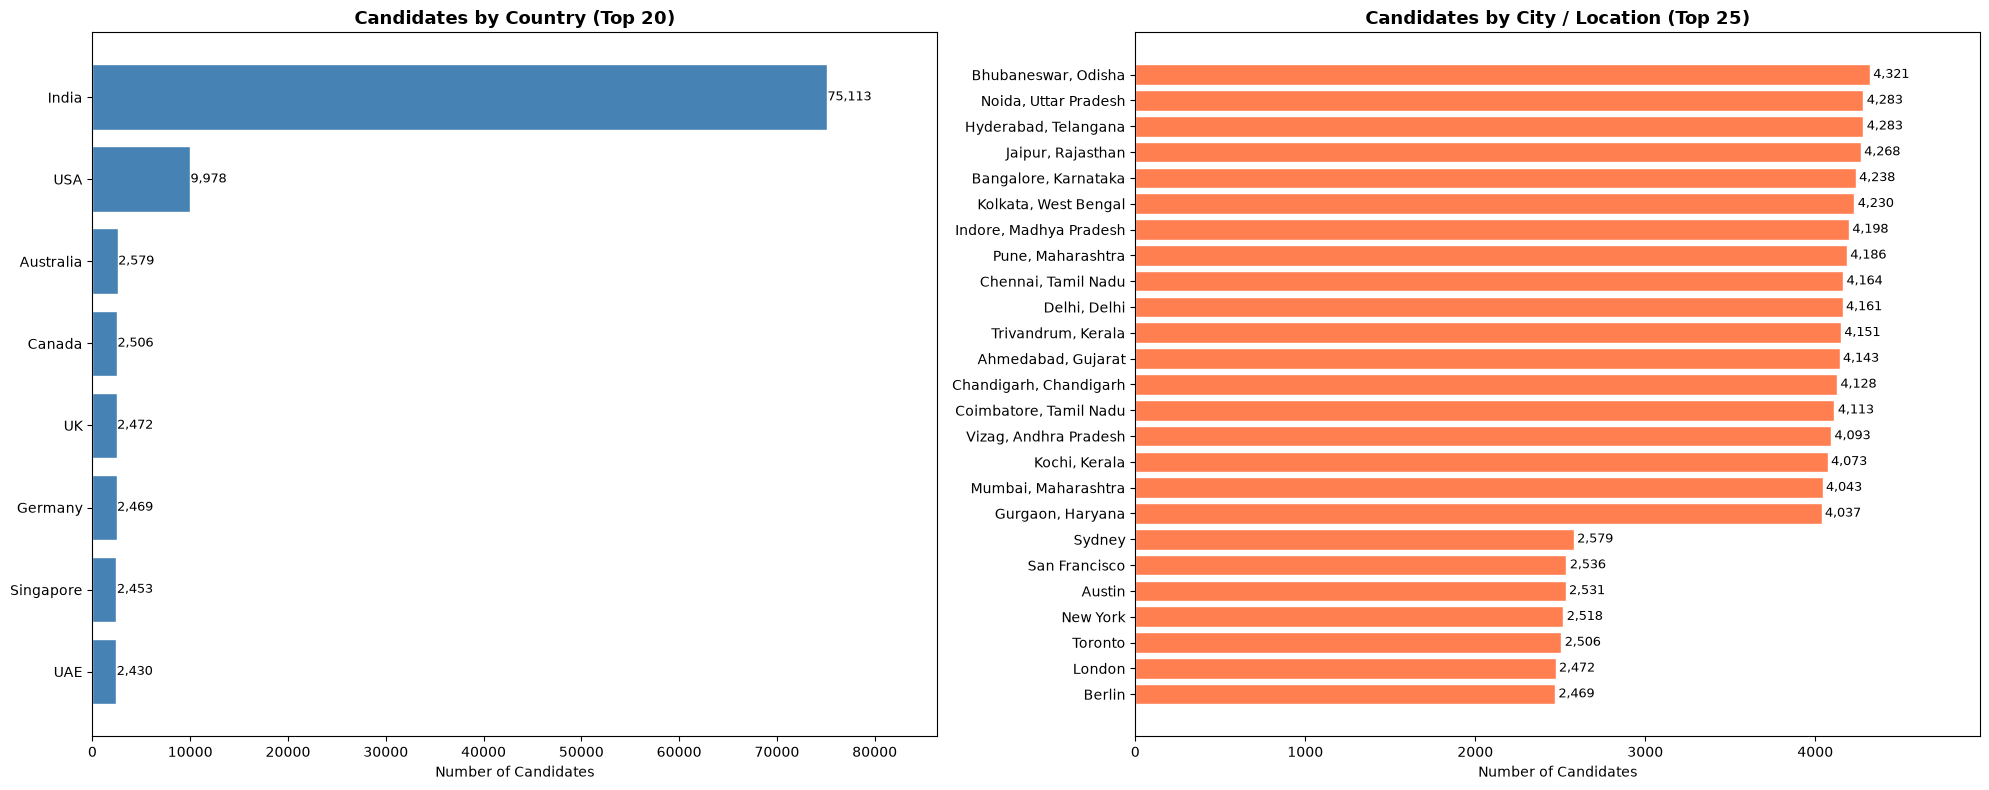


Unique countries : 8
Unique locations : 28


In [18]:
from collections import Counter
import matplotlib.pyplot as plt

country_counts  = Counter(df_locations['country'].str.strip().replace('', 'Unknown'))
location_counts = Counter(df_locations['location'].str.strip().replace('', 'Unknown'))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Country bar chart ---
top_countries = pd.DataFrame(country_counts.most_common(20), columns=['Country', 'Count'])
bars = axes[0].barh(top_countries['Country'][::-1], top_countries['Count'][::-1],
                    color='steelblue', edgecolor='white')
for bar, val in zip(bars, top_countries['Count'][::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlabel('Number of Candidates')
axes[0].set_title('Candidates by Country (Top 20)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, top_countries['Count'].max() * 1.15)

# --- City/location bar chart ---
top_locations = pd.DataFrame(location_counts.most_common(25), columns=['Location', 'Count'])
bars2 = axes[1].barh(top_locations['Location'][::-1], top_locations['Count'][::-1],
                     color='coral', edgecolor='white')
for bar, val in zip(bars2, top_locations['Count'][::-1]):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Candidates by City / Location (Top 25)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, top_locations['Count'].max() * 1.15)

plt.tight_layout()
plt.show()

print(f'\nUnique countries : {len(country_counts)}')
print(f'Unique locations : {len(location_counts)}')

From India     : 75,113
Not from India : 24,887
Total          : 100,000


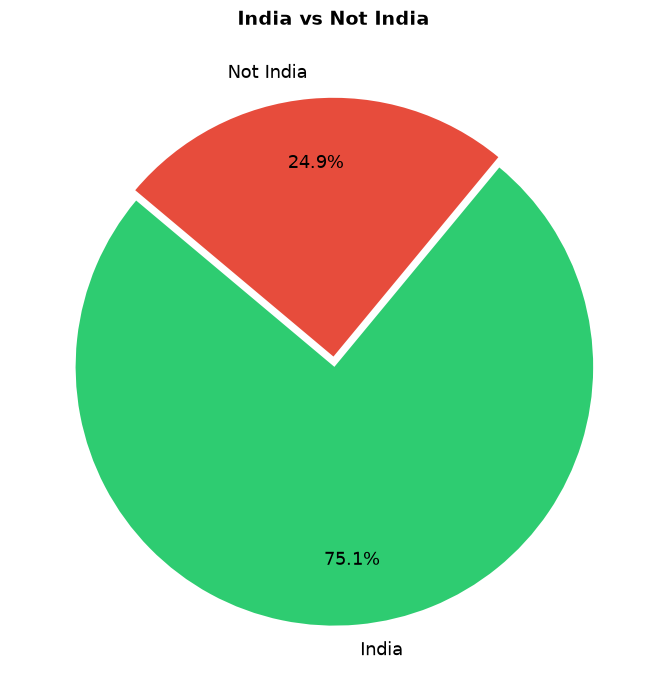

In [19]:
import matplotlib.pyplot as plt

india_mask   = df_locations['country'].str.strip().str.lower() == 'india'
df_india     = df_locations[india_mask].reset_index(drop=True)
df_not_india = df_locations[~india_mask].reset_index(drop=True)

print(f"From India     : {len(df_india):,}")
print(f"Not from India : {len(df_not_india):,}")
print(f"Total          : {len(df_locations):,}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [len(df_india), len(df_not_india)],
    labels=['India', 'Not India'],
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.04, 0),
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 13},
    pctdistance=0.75,
)
ax.set_title('India vs Not India', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Segment breakdown:
  Preferred       : 8,469  (11.3%)
  Welcome         : 16,524  (22.0%)
  Rest of India   : 50,120  (66.7%)


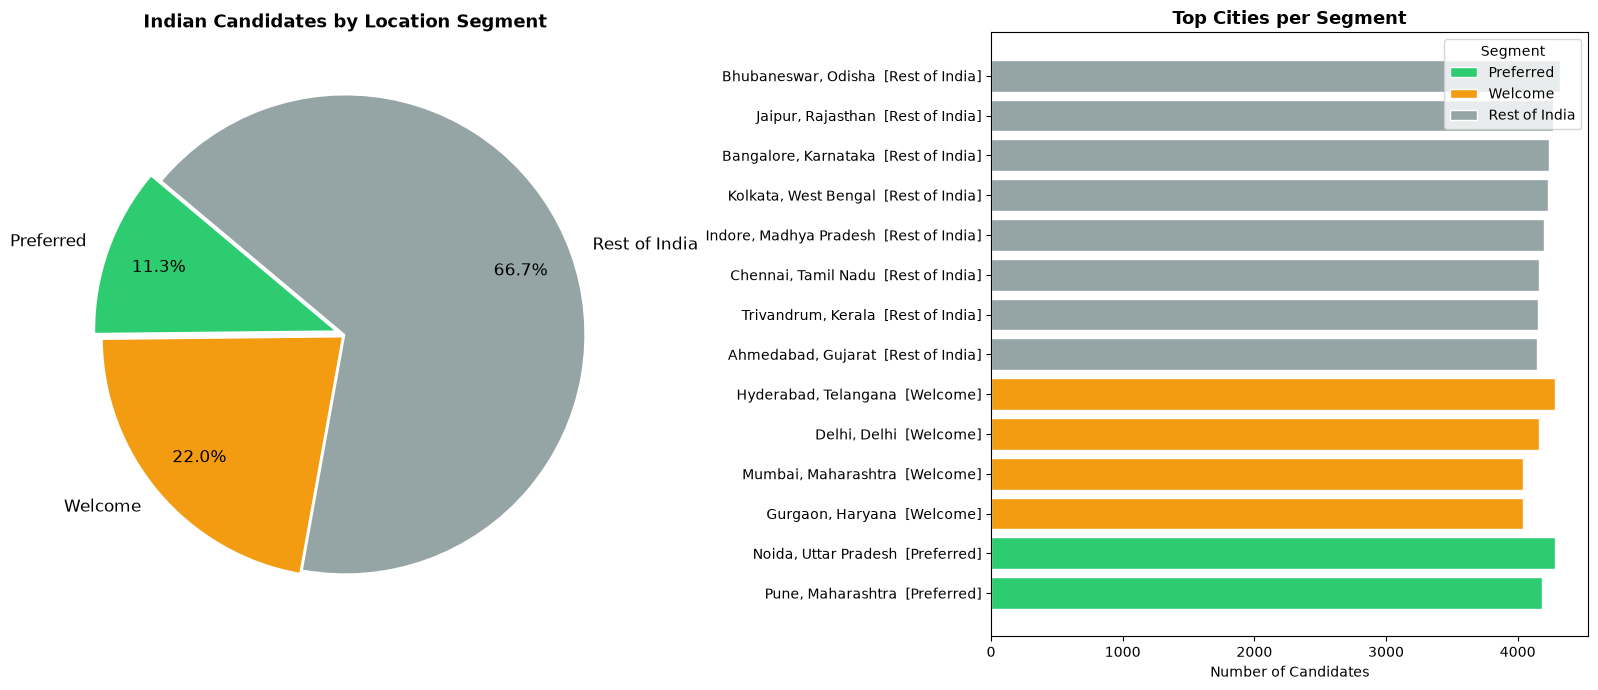

In [20]:
import matplotlib.pyplot as plt

PREFERRED = ['pune', 'noida']
WELCOME     = ['mumbai', 'delhi', 'hyderabad', 'gurgaon']

def location_segment(loc):
    l = (loc or '').lower()
    if any(city in l for city in PREFERRED):
        return 'Preferred'
    if any(city in l for city in WELCOME):
        return 'Welcome'
    return 'Rest of India'

df_india_seg = df_india.copy()
df_india_seg['segment'] = df_india_seg['location'].apply(location_segment)

seg_counts = df_india_seg['segment'].value_counts().reindex(['Preferred', 'Welcome', 'Rest of India'], fill_value=0)

print("Segment breakdown:")
for seg, cnt in seg_counts.items():
    print(f"  {seg:<16}: {cnt:,}  ({100*cnt/len(df_india_seg):.1f}%)")

# --- Side-by-side: pie + stacked bar by top cities ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie
colors = {'Preferred': '#2ecc71', 'Welcome': '#f39c12', 'Rest of India': '#95a5a6'}
axes[0].pie(
    seg_counts,
    labels=seg_counts.index,
    colors=[colors[s] for s in seg_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    explode=(0.05, 0.02, 0),
    textprops={'fontsize': 12},
    pctdistance=0.78,
)
axes[0].set_title('Indian Candidates by Location Segment', fontsize=13, fontweight='bold')

# Top cities within each segment
top_cities = (
    df_india_seg.groupby(['segment', 'location'])
    .size()
    .reset_index(name='count')
    .sort_values(['segment', 'count'], ascending=[True, False])
)

for seg, color in colors.items():
    subset = top_cities[top_cities['segment'] == seg].head(8)
    axes[1].barh(
        subset['location'][::-1] + f'  [{seg}]',
        subset['count'][::-1],
        color=color, edgecolor='white', label=seg
    )

axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Top Cities per Segment', fontsize=13, fontweight='bold')
axes[1].legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.show() 

── Non-India clean candidates ──
  Total          : 1,982
  Willing        : 613  (30.9%)
  Not willing    : 1,369  (69.1%)
  Unknown        : 0


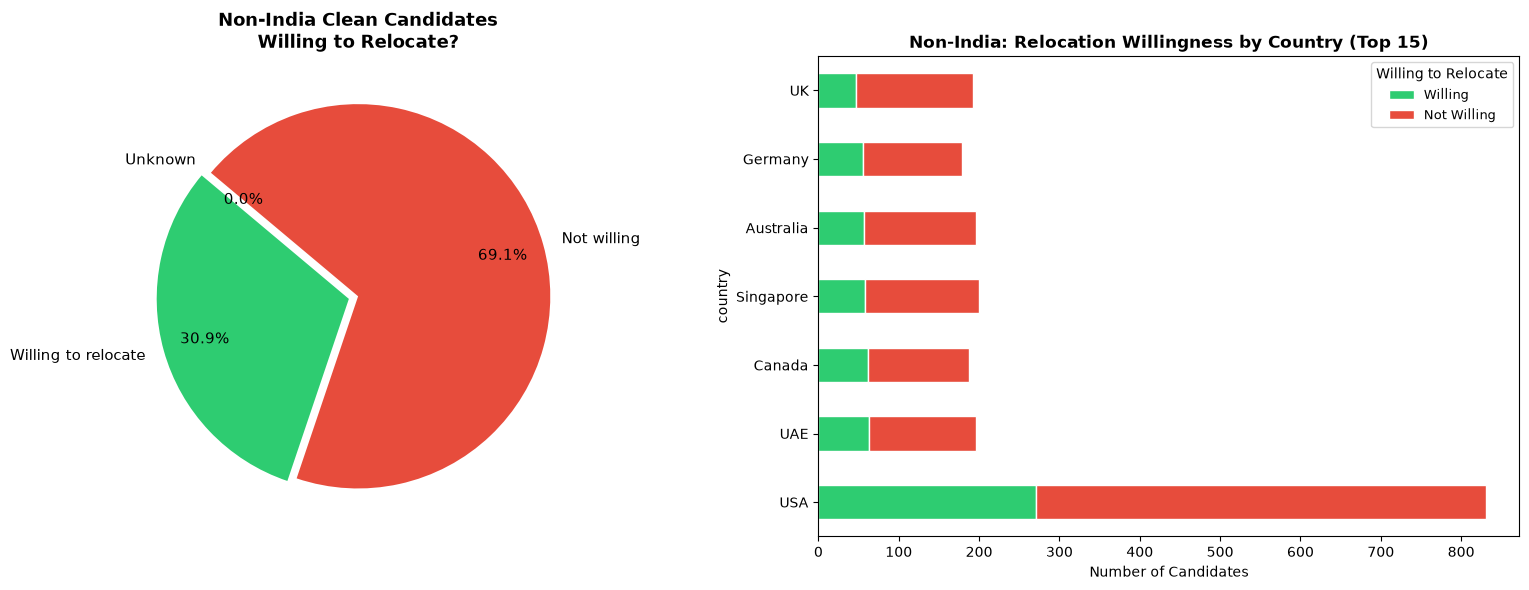

In [21]:
import matplotlib.pyplot as plt

# Build enriched dataframe for clean candidates: location + relocation signal
clean_loc_rows = []
for cid in clean_ids:
    c        = id_to_record.get(cid, {})
    profile  = c.get('profile', {}) or {}
    signals  = c.get('redrob_signals', {}) or {}
    clean_loc_rows.append({
        'candidate_id'       : cid,
        'country'            : (profile.get('country')  or '').strip(),
        'location'           : (profile.get('location') or '').strip(),
        'willing_to_relocate': signals.get('willing_to_relocate', None),
    })

df_clean_loc = (
    pd.DataFrame(clean_loc_rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

# Non-Indian resident candidates
df_non_india = df_clean_loc[df_clean_loc['country'].str.lower() != 'india'].copy()

willing     = int((df_non_india['willing_to_relocate'] == True).sum())
not_willing = int((df_non_india['willing_to_relocate'] == False).sum())
unknown     = len(df_non_india) - willing - not_willing

print("── Non-India clean candidates ──")
print(f"  Total          : {len(df_non_india):,}")
print(f"  Willing        : {willing:,}  ({100*willing/len(df_non_india):.1f}%)")
print(f"  Not willing    : {not_willing:,}  ({100*not_willing/len(df_non_india):.1f}%)")
print(f"  Unknown        : {unknown:,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie: willing to relocate
axes[0].pie(
    [willing, not_willing, unknown],
    labels=['Willing to relocate', 'Not willing', 'Unknown'],
    colors=['#2ecc71', '#e74c3c', '#95a5a6'],
    explode=(0.05, 0, 0),
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11},
    pctdistance=0.78,
)
axes[0].set_title('Non-India Clean Candidates\nWilling to Relocate?', fontsize=13, fontweight='bold')

# Bar: country breakdown, coloured by willing/not
country_reloc = (
    df_non_india.groupby(['country', 'willing_to_relocate'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: 'Willing', False: 'Not Willing', None: 'Unknown'})
)
country_reloc = country_reloc.reindex(
    columns=[c for c in ['Willing', 'Not Willing', 'Unknown'] if c in country_reloc.columns]
)
country_reloc = country_reloc.sort_values('Willing', ascending=False).head(15)
country_reloc.plot(kind='barh', ax=axes[1], color=['#2ecc71', '#e74c3c', '#95a5a6'],
                   edgecolor='white', stacked=True)
axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Non-India: Relocation Willingness by Country (Top 15)', fontsize=12, fontweight='bold')
axes[1].legend(title='Willing to Relocate', fontsize=9)

plt.tight_layout()
plt.show()


── India clean candidates ──
  Total India                         : 6,749
  Preferred (Pune/Noida)              : 744
  Welcome cities — willing to relocate: 484  (of 1,493)
  Rest of India — willing to relocate : 1,502  (of 4,512)


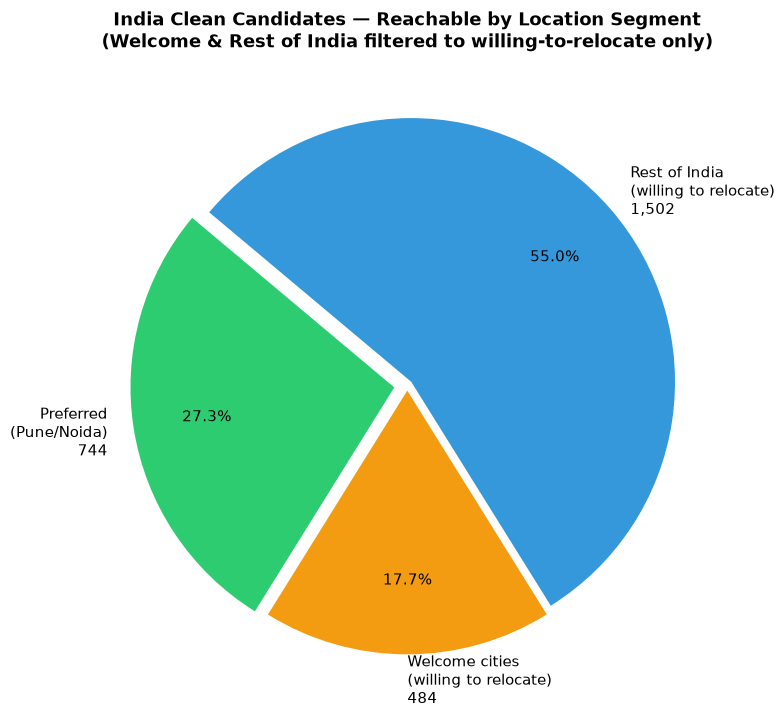

In [22]:
import matplotlib.pyplot as plt

PREFERRED = ['pune', 'noida']
WELCOME   = ['mumbai', 'delhi', 'hyderabad', 'gurgaon']

df_india_clean = df_clean_loc[df_clean_loc['country'].str.lower() == 'india'].copy()

def india_segment(loc):
    l = (loc or '').lower()
    if any(city in l for city in PREFERRED): return 'Preferred'
    if any(city in l for city in WELCOME):   return 'Welcome'
    return 'Rest of India'

df_india_clean['segment'] = df_india_clean['location'].apply(india_segment)

# Preferred — count all (no relocation needed)
n_preferred = int((df_india_clean['segment'] == 'Preferred').sum())

# Welcome — count only willing_to_relocate == True
n_welcome_willing = int(
    ((df_india_clean['segment'] == 'Welcome') &
     (df_india_clean['willing_to_relocate'] == True)).sum()
)
n_welcome_total = int((df_india_clean['segment'] == 'Welcome').sum())

# Rest of India — count only willing_to_relocate == True
n_rest_willing = int(
    ((df_india_clean['segment'] == 'Rest of India') &
     (df_india_clean['willing_to_relocate'] == True)).sum()
)
n_rest_total = int((df_india_clean['segment'] == 'Rest of India').sum())

print("── India clean candidates ──")
print(f"  Total India                         : {len(df_india_clean):,}")
print(f"  Preferred (Pune/Noida)              : {n_preferred:,}")
print(f"  Welcome cities — willing to relocate: {n_welcome_willing:,}  (of {n_welcome_total:,})")
print(f"  Rest of India — willing to relocate : {n_rest_willing:,}  (of {n_rest_total:,})")

# Pie: reachable candidates by segment
fig, ax = plt.subplots(figsize=(8, 8))

labels = [
    f'Preferred\n(Pune/Noida)\n{n_preferred:,}',
    f'Welcome cities\n(willing to relocate)\n{n_welcome_willing:,}',
    f'Rest of India\n(willing to relocate)\n{n_rest_willing:,}',
]
sizes  = [n_preferred, n_welcome_willing, n_rest_willing]
colors = ['#2ecc71', '#f39c12', '#3498db']

ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    explode=(0.05, 0.02, 0.02),
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 11},
    pctdistance=0.72,
)
ax.set_title(
    'India Clean Candidates — Reachable by Location Segment\n'
    '(Welcome & Rest of India filtered to willing-to-relocate only)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


In [23]:
n_india_willing = int((df_india_clean['willing_to_relocate'] == True).sum())
print(f"India clean candidates willing to relocate : {n_india_willing:,}  (of {len(df_india_clean):,} total India)")


India clean candidates willing to relocate : 2,243  (of 6,749 total India)


<h3> Inspecting Candidate Notice Periods </h3>

In [24]:
import matplotlib.pyplot as plt

# Extract candidate_id and notice_period_days from redrob_signals
df_notice = pd.DataFrame([
    {
        'candidate_id'       : c.get('candidate_id', ''),
        'notice_period_days' : (c.get('redrob_signals', {}) or {}).get('notice_period_days'),
    }
    for c in records
]).sort_values('candidate_id').reset_index(drop=True)

df_notice['notice_period_days'] = pd.to_numeric(df_notice['notice_period_days'], errors='coerce')

def notice_group(days):
    if pd.isna(days):
        return 'Unknown'
    return 'Up to 30 days' if days <= 30 else '> 30 days'

df_notice['group'] = df_notice['notice_period_days'].apply(notice_group)

group_counts = df_notice['group'].value_counts().reindex(['Up to 30 days', '> 30 days', 'Unknown'])

print("Notice period breakdown:")
for grp, cnt in group_counts.items():
    print(f"  {grp:<16}: {cnt:,}  ({100 * cnt / len(df_notice):.1f}%)")


Notice period breakdown:
  Up to 30 days   : 13,809.0  (13.8%)
  > 30 days       : 86,191.0  (86.2%)
  Unknown         : nan  (nan%)


<h2> Behavioural Signals </h2>

In [25]:
#List all the behavioural signals.

signal_keys = set()
for c in records:
    signal_keys.update((c.get('redrob_signals') or {}).keys())

print(f"Total behavioural signals: {len(signal_keys)}\n")
for i, key in enumerate(sorted(signal_keys), 1):
    # Sample a non-null value to show the data type
    sample = next(
        (c['redrob_signals'][key] for c in records
         if key in (c.get('redrob_signals') or {}) and c['redrob_signals'][key] is not None),
        None
    )
    print(f"  {i:>2}. {key:<40} example: {sample}")

Total behavioural signals: 23

   1. applications_submitted_30d               example: 2
   2. avg_response_time_hours                  example: 177.8
   3. connection_count                         example: 356
   4. endorsements_received                    example: 35
   5. expected_salary_range_inr_lpa            example: {'min': 18.7, 'max': 36.1}
   6. github_activity_score                    example: 9.2
   7. interview_completion_rate                example: 0.71
   8. last_active_date                         example: 2026-05-20
   9. linkedin_connected                       example: False
  10. notice_period_days                       example: 60
  11. offer_acceptance_rate                    example: 0.58
  12. open_to_work_flag                        example: True
  13. preferred_work_mode                      example: onsite
  14. profile_completeness_score               example: 86.9
  15. profile_views_received_30d               example: 23
  16. recruiter_response_rate    

## Full Clean-Candidate Profile DataFrame

One row per candidate that passes both filters (no consulting-only, no fictional company).  
- `profile_*` — all 10 profile scalar fields, flattened  
- `signals_*` — all 23 redrob_signal fields, flattened (sub-dicts kept as Python objects)  
- `career_history`, `skills`, `education`, `certifications`, `languages` — kept as Python lists (click a cell to inspect)

In [26]:
# Uses: clean_ids, id_to_record  (defined in earlier cells above)

rows = []
for cid in clean_ids:
    c   = id_to_record.get(cid, {})
    row = {"candidate_id": cid}

    for k, v in (c.get("profile") or {}).items():
        row[f"profile_{k}"] = v

    for k, v in (c.get("redrob_signals") or {}).items():
        row[f"signals_{k}"] = v          # sub-dicts (salary range, assessment scores) kept as-is

    for field in ("career_history", "skills", "education", "certifications", "languages"):
        row[field] = c.get(field, [])    # lists kept as Python objects — inspectable in cells

    rows.append(row)

df_clean_full = (
    pd.DataFrame(rows)
    .sort_values("candidate_id")
    .reset_index(drop=True)
)

print(f"Clean candidates : {len(df_clean_full):,}")
print(f"Columns          : {len(df_clean_full.columns)}")
print("\nAll columns:")
for i, col in enumerate(df_clean_full.columns, 1):
    print(f"  {i:>2}. {col}")

df_clean_full

Clean candidates : 8,731
Columns          : 39

All columns:
   1. candidate_id
   2. profile_anonymized_name
   3. profile_headline
   4. profile_summary
   5. profile_location
   6. profile_country
   7. profile_years_of_experience
   8. profile_current_title
   9. profile_current_company
  10. profile_current_company_size
  11. profile_current_industry
  12. signals_profile_completeness_score
  13. signals_signup_date
  14. signals_last_active_date
  15. signals_open_to_work_flag
  16. signals_profile_views_received_30d
  17. signals_applications_submitted_30d
  18. signals_recruiter_response_rate
  19. signals_avg_response_time_hours
  20. signals_skill_assessment_scores
  21. signals_connection_count
  22. signals_endorsements_received
  23. signals_notice_period_days
  24. signals_expected_salary_range_inr_lpa
  25. signals_preferred_work_mode
  26. signals_willing_to_relocate
  27. signals_github_activity_score
  28. signals_search_appearance_30d
  29. signals_saved_by_recruiter

,candidate_id,profile_anonymized_name,profile_headline,profile_summary,profile_location,profile_country,profile_years_of_experience,profile_current_title,profile_current_company,profile_current_company_size,...,signals_interview_completion_rate,signals_offer_acceptance_rate,signals_verified_email,signals_verified_phone,signals_linkedin_connected,career_history,skills,education,certifications,languages
0,CAND_0000010,Aarav Kapoor,Data Engineer | Data pipelines & analytics,Software / data professional with 4.6 years of...,London,UK,4.6,Data Engineer,Ola,5001-10000,...,0.53,-1.00,True,True,False,"[{'company': 'Ola', 'title': 'Data Engineer', ...","[{'name': 'GCP', 'proficiency': 'beginner', 'e...","[{'institution': 'Generic State University', '...",[],"[{'language': 'English', 'proficiency': 'nativ..."
1,CAND_0000025,Anika Kumar,Frontend Engineer | Cloud & DevOps,Software engineer with 7.3 years of experience...,"Vizag, Andhra Pradesh",India,7.3,Frontend Engineer,Tech Mahindra,10001+,...,0.70,-1.00,True,True,True,"[{'company': 'Tech Mahindra', 'title': 'Fronte...","[{'name': 'JavaScript', 'proficiency': 'interm...",[{'institution': 'Regional Technical Institute...,"[{'name': 'Six Sigma Green Belt', 'issuer': 'A...","[{'language': 'English', 'proficiency': 'profe..."
2,CAND_0000031,Ela Singh,"Recommendation Systems Engineer | Search, Rank...",Machine learning engineer with 6.0 years of ex...,"Hyderabad, Telangana",India,6.0,Recommendation Systems Engineer,Swiggy,5001-10000,...,0.60,0.38,False,True,False,"[{'company': 'Swiggy', 'title': 'Recommendatio...","[{'name': 'Go', 'proficiency': 'intermediate',...","[{'institution': 'SRM University', 'degree': '...",[],"[{'language': 'English', 'proficiency': 'nativ..."
3,CAND_0000051,Meera Arora,Cloud Engineer | Cloud & DevOps,Software engineer with 6.2 years of experience...,Dubai,UAE,6.2,Cloud Engineer,HCL,10001+,...,0.93,0.63,True,False,False,"[{'company': 'HCL', 'title': 'Cloud Engineer',...","[{'name': 'Databricks', 'proficiency': 'beginn...","[{'institution': 'Local Engineering College', ...",[],"[{'language': 'English', 'proficiency': 'nativ..."
4,CAND_0000055,Pari Tiwari,Full Stack Developer | Backend systems & APIs,Software engineer with 7.3 years of experience...,"Indore, Madhya Pradesh",India,7.3,Full Stack Developer,Razorpay,1001-5000,...,0.48,-1.00,True,True,False,"[{'company': 'Razorpay', 'title': 'Full Stack ...","[{'name': 'Reinforcement Learning', 'proficien...","[{'institution': 'Tier-3 Engineering College',...","[{'name': 'Six Sigma Green Belt', 'issuer': 'A...","[{'language': 'English', 'proficiency': 'profe..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8726,CAND_0099965,Ayaan Vora,Junior ML Engineer | 4.6 yrs in analytics & ML,Data scientist / ML engineer with 4.6 years of...,"Kochi, Kerala",India,4.6,Junior ML Engineer,Niramai,51-200,...,0.93,-1.00,True,False,True,"[{'company': 'Niramai', 'title': 'Junior ML En...","[{'name': 'Forecasting', 'proficiency': 'inter...","[{'institution': 'NIT Surathkal', 'degree': 'B...",[],"[{'language': 'English', 'proficiency': 'nativ..."
8727,CAND_0099983,Anjali Shah,"Data Engineer | SQL, Spark, Cloud",Software / data professional with 5.3 years of...,"Trivandrum, Kerala",India,5.3,Data Engineer,upGrad,1001-5000,...,0.62,0.72,True,True,True,"[{'company': 'upGrad', 'title': 'Data Engineer...","[{'name': 'Computer Vision', 'proficiency': 'i...","[{'institution': 'COEP Pune', 'degree': 'B.E.'...","[{'name': 'Six Sigma Green Belt', 'issuer': 'A...","[{'language': 'English', 'proficiency': 'profe..."
8728,CAND_0099984,Dev Joshi,Analytics Engineer | 3.0+ yrs in data engineering,Software / data professional with 3.0 years of...,"Kochi, Kerala",India,3.0,Analytics Engineer,PharmEasy,5001-10000,...,0.80,-1.00,True,True,False,"[{'company': 'PharmEasy', 'title': 'Analytics ...","[{'name': 'MongoDB', 'proficiency': 'beginner'...",[{'institution': 'Lovely Professional Universi...,[],"[{'language': 'Eng

In [28]:
pprint.pprint(records[6366])

{'candidate_id': 'CAND_0006367',
 'career_history': [{'company': 'Razorpay',
                     'company_size': '1001-5000',
                     'description': 'Frontend engineering at a media company. '
                                    'React, TypeScript, and the typical '
                                    'surrounding tooling (Webpack, Jest, '
                                    "Cypress). Built the company's design "
                                    'system from scratch and led the migration '
                                    'from a legacy AngularJS app. Strong on '
                                    'the frontend craft — accessibility, '
                                    'performance, animations — but limited '
                                    'backend exposure.',
                     'duration_months': 12,
                     'end_date': None,
                     'industry': 'Fintech',
                     'is_current': True,
                     'start_date